In [3]:
#Test Set Evaluation. Here we will compare the models output with the test set. Will use Mean Absolute Error, Root Mean Squared Error and Mean absolute percentage error. 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import joblib
import os

sns.set_theme(style="whitegrid")

# Load Data and Models
df = pd.read_csv("../data/processed/featured_dataset.csv", index_col=0, parse_dates=True)
target_col = 'Max. Demand at eve. peak (Generation end)'
X = df.drop(columns=[target_col] + [col for col in df.columns if 'load' in col.lower()])
y = df[target_col]

split_idx = int(len(df) * 0.8)
X_test, y_test = X.iloc[split_idx:], y.iloc[split_idx:]

ridge_model = joblib.load('../models/best_ridge_model.pkl')
rf_model = joblib.load('../models/best_rf_model.pkl')

# Generate Predictions
baseline_preds = X_test['Demand_Lag1']
ridge_preds = ridge_model.predict(X_test)
rf_preds = rf_model.predict(X_test)

# Calculate Metrics
def get_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAPE': mean_absolute_percentage_error(y_true, y_pred) * 100
    }

results = pd.DataFrame({
    'Baseline (Lag 1)': get_metrics(y_test, baseline_preds),
    'Ridge Regression': get_metrics(y_test, ridge_preds),
    'Random Forest': get_metrics(y_test, rf_preds)
}).T

print("--- Final Test Set Performance ---")
print(results.round(2))

--- Final Test Set Performance ---
                      MAE     RMSE   MAPE
Baseline (Lag 1)  1224.30  1793.16  10.02
Ridge Regression   209.86   293.55   1.71
Random Forest      301.34   397.07   2.38


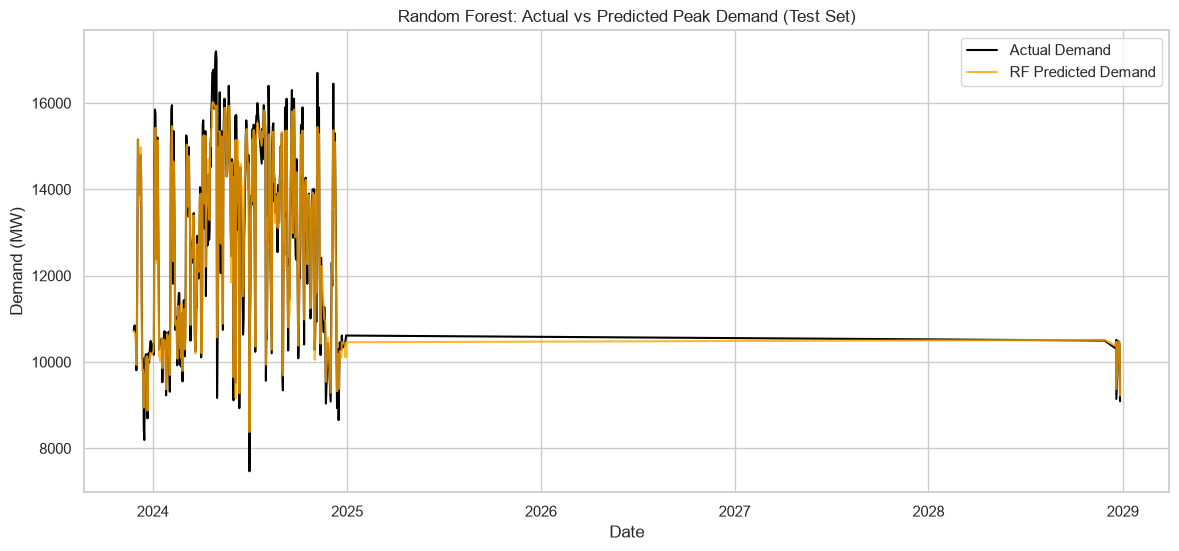

C:\Users\Asus\AppData\Local\Temp\ipykernel_28816\2765132312.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='viridis')


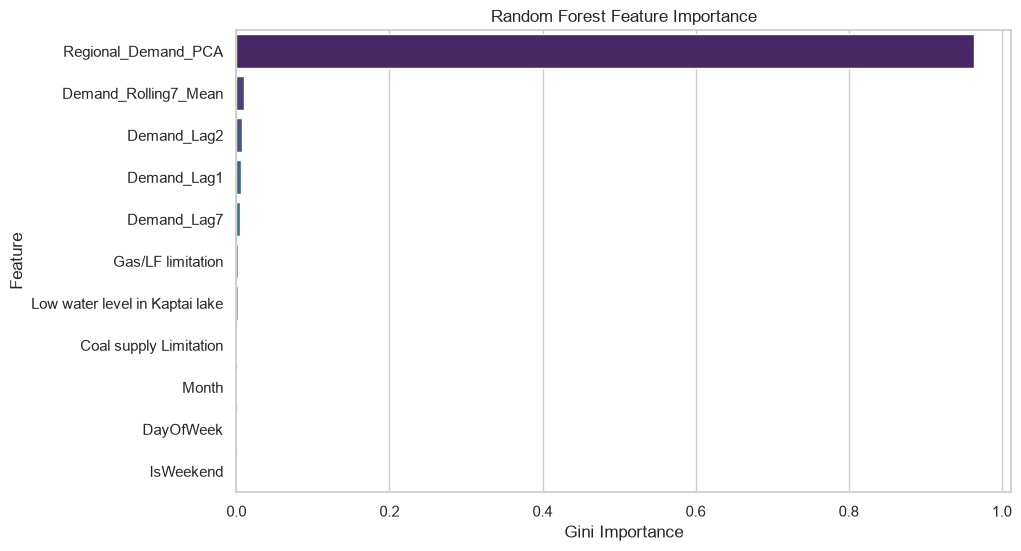

In [4]:
#Visualization and Feacture Importance. 

# Actual vs Predicted Plot
plt.figure(figsize=(14, 6))
plt.plot(y_test.index, y_test.values, label='Actual Demand', color='black', linewidth=1.5)
plt.plot(y_test.index, rf_preds, label='RF Predicted Demand', color='orange', alpha=0.8)
plt.title('Random Forest: Actual vs Predicted Peak Demand (Test Set)')
plt.xlabel('Date')
plt.ylabel('Demand (MW)')
plt.legend()
plt.savefig('../figures/03_actual_vs_predicted.png', bbox_inches='tight')
plt.show()

# Feature Importance Plot from Random Forest
rf_regressor = rf_model  
importances = rf_regressor.feature_importances_
feature_names = X_test.columns

feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='viridis')
plt.title('Random Forest Feature Importance')
plt.xlabel('Gini Importance')
plt.savefig('../figures/04_feature_importance.png', bbox_inches='tight')
plt.show()

In [5]:
#Error Analysis 

# Calculating residual errors 
errors = y_test - rf_preds
error_df = pd.DataFrame({'Actual': y_test, 'Predicted': rf_preds, 'Error': errors, 'Abs_Error': np.abs(errors)})
error_df = error_df.join(X_test) 

# Find the Worst Predictions
worst_predictions = error_df.sort_values(by='Abs_Error', ascending=False).head(5)

print("--- Top 5 Worst Predictions (Largest Errors) ---")
for index, row in worst_predictions.iterrows():
    print(f"Date: {index.date()} | Actual: {row['Actual']} MW | Predicted: {row['Predicted']:.0f} MW | Error: {row['Error']:.0f} MW")
    print(f"   Context -> DayOfWeek: {row['DayOfWeek']}, Gas Limitation: {row['Gas/LF limitation']}, Temp (approx): {df.loc[index, 'Maximum Temperature in Dhaka was'] if 'Maximum Temperature in Dhaka was' in df.columns else 'N/A'}")
    print("-" * 50)

--- Top 5 Worst Predictions (Largest Errors) ---
Date: 2024-05-01 | Actual: 9168.0 MW | Predicted: 10572 MW | Error: -1404 MW
   Context -> DayOfWeek: 2.0, Gas Limitation: 4452.0, Temp (approx): N/A
--------------------------------------------------
Date: 2024-04-29 | Actual: 17200.0 MW | Predicted: 15938 MW | Error: 1262 MW
   Context -> DayOfWeek: 0.0, Gas Limitation: 1035.0, Temp (approx): N/A
--------------------------------------------------
Date: 2024-11-06 | Actual: 16700.0 MW | Predicted: 15447 MW | Error: 1253 MW
   Context -> DayOfWeek: 2.0, Gas Limitation: 3734.0, Temp (approx): N/A
--------------------------------------------------
Date: 2024-04-28 | Actual: 17150.0 MW | Predicted: 15903 MW | Error: 1247 MW
   Context -> DayOfWeek: 6.0, Gas Limitation: 1026.0, Temp (approx): N/A
--------------------------------------------------
Date: 2024-08-06 | Actual: 16400.0 MW | Predicted: 15194 MW | Error: 1206 MW
   Context -> DayOfWeek: 1.0, Gas Limitation: 3466.0, Temp (approx): N